In [1]:
import math

import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from CRU import CRUs, RyR_stationary, LCC_stationary
from params import RestrepoParams
#from currents import get_ICa

In [2]:
ci = 0.1 * np.ones((200, 200), dtype=np.float32)
cs = 0.1 * np.ones((200, 200), dtype=np.float32)
cp = 0.1 * np.ones((200, 200), dtype=np.float32)

cjsr = 750.0 * np.ones((200,200), dtype=np.float32)
cnsr = 750.0 * np.ones((200,200), dtype=np.float32)

CaTi = 20.0 * np.ones((200,200), dtype=np.float32)
CaTs = 20.0 * np.ones((200,200), dtype=np.float32)

params = RestrepoParams()

In [3]:
RyR = RyR_stationary(cp, params)

In [4]:
LCC = LCC_stationary(cp, 0.1, params)

In [5]:
cru_obj = CRUs(RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs)

In [58]:
cru_obj.forward(0.1, 100.0, 1e-3, nstep=1000)

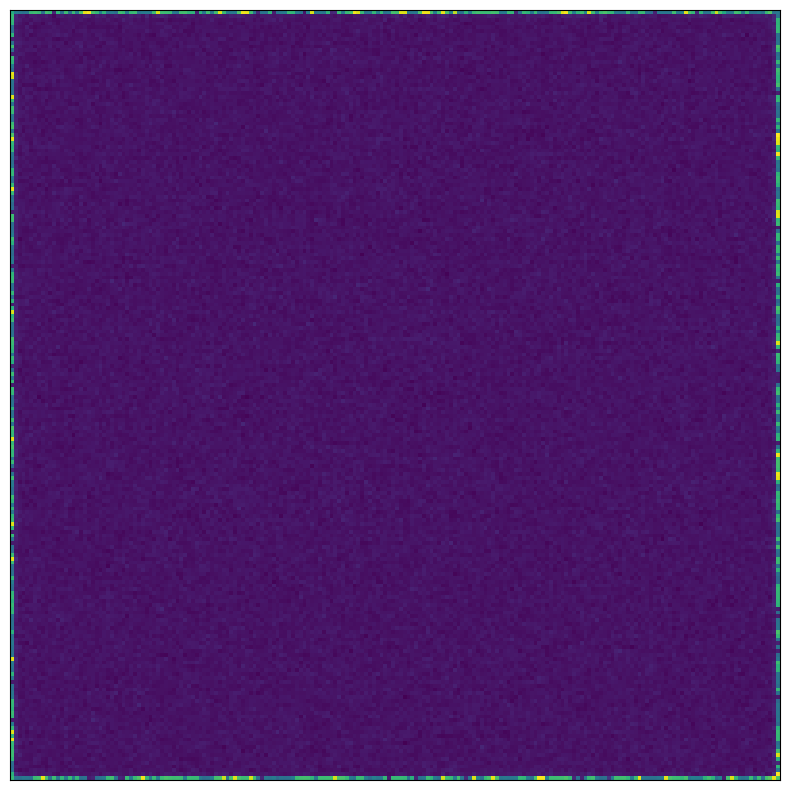

In [59]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(cru_obj.cs, aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
plt.show()

In [69]:
ci_int = cru_obj.ci[1:-1, 1:-1]

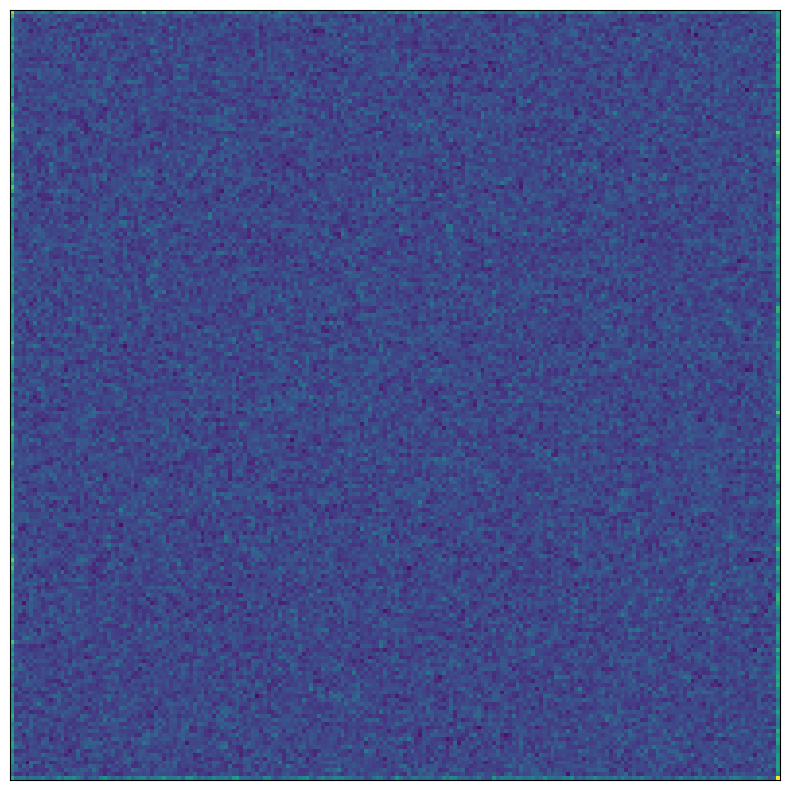

In [70]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(ci_int, aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
plt.show()

In [95]:
from scipy.fft import fft2, fftfreq

In [82]:
modes = fft2(ci_int - ci_int.mean(), norm="ortho")

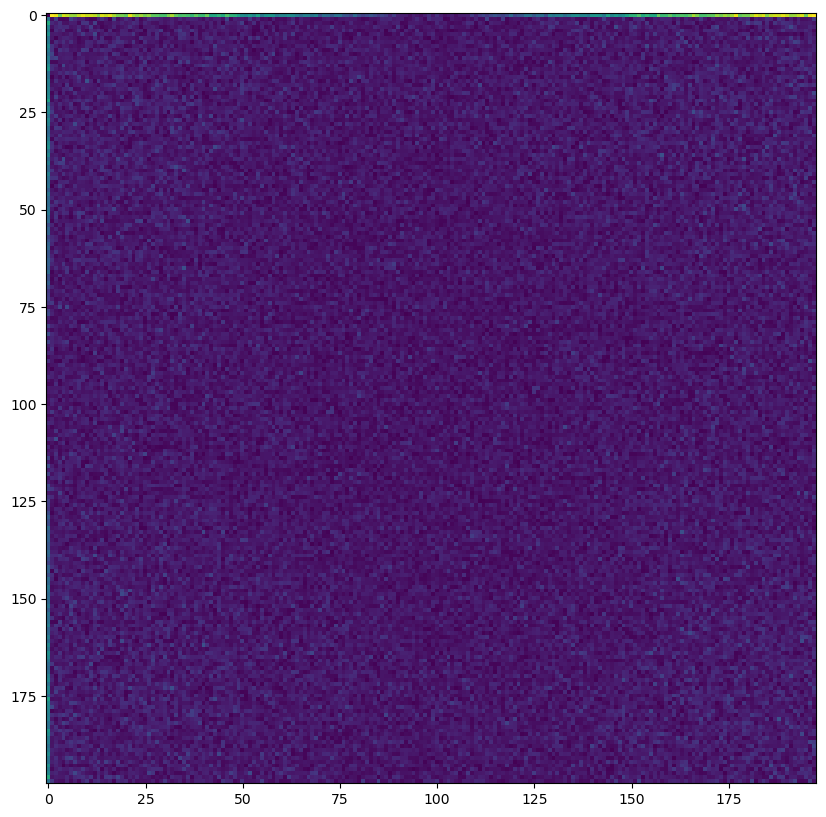

In [86]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(np.abs(modes))
plt.show()

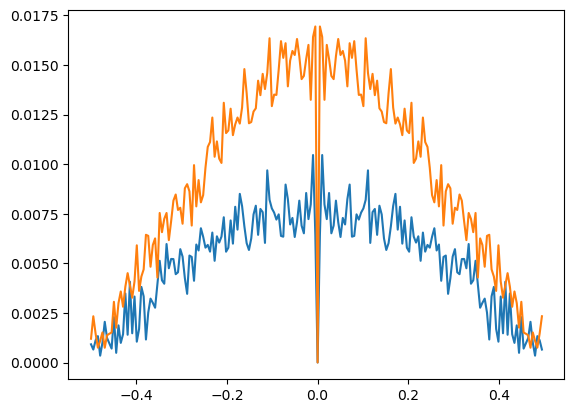

In [104]:
freqs = fftfreq(modes[0,:].shape[0])
idx = freqs.argsort()
plt.plot(freqs[idx], np.abs(modes)[idx, 0])
plt.plot(freqs[idx], np.abs(modes)[0, idx])
plt.show()

In [12]:
dW_h = cru_obj.dW.copy_to_host()
rates_h = cru_obj.RyR_rates.copy_to_host()

RyR_test = test_RyR_cpu(RyR, rates_h, dW_h, 5e-3)

In [13]:
np.allclose(cru_obj.RyR, RyR_test)

True